### DCE Crush Spread Analysis - Daily Data

Hypothesis: Crush spread is a stationary, mean reverting spread due to economic ties to the physical margins. Making dislocations to the margin a tradable strategy.

In [1]:
import pandas as pd


import utilities, features
import matplotlib.pyplot as plt
import seaborn as sns

from theme import set_theme
from utilities import ad_fuller_test

set_theme()

{'rc_params': {'figure.facecolor': '#fcfcfb',
  'axes.facecolor': '#fcfcfb',
  'savefig.facecolor': '#fcfcfb',
  'axes.edgecolor': '#898781',
  'axes.labelcolor': '#52514e',
  'axes.titlecolor': '#0b0b0b',
  'axes.titlelocation': 'left',
  'axes.titlesize': 11,
  'axes.titleweight': 'bold',
  'axes.spines.top': False,
  'axes.spines.right': False,
  'text.color': '#0b0b0b',
  'xtick.color': '#52514e',
  'ytick.color': '#52514e',
  'axes.grid': True,
  'axes.grid.axis': 'y',
  'grid.color': '#e6e5e1',
  'grid.linewidth': 0.8,
  'grid.linestyle': '-',
  'lines.linewidth': 1.8,
  'legend.frameon': False,
  'font.size': 9.5,
  'text.parse_math': False},
 'palette': ['#2a78d6',
  '#eb6834',
  '#1baf7a',
  '#eda100',
  '#e87ba4',
  '#008300',
  '#4a3aa7',
  '#e34948'],
 'colors': {'surface': '#fcfcfb',
  'ink': '#0b0b0b',
  'ink_secondary': '#52514e',
  'muted': '#898781',
  'grid': '#e6e5e1',
  'neutral': '#f0efec',
  'palette': ['#2a78d6',
   '#eb6834',
   '#1baf7a',
   '#eda100',
   '#e87

In [2]:
PATH = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\raw\soy_complex_flat.parquet"
df = pd.read_parquet(PATH)

In [3]:
# Add in log returns for each contract
ret_df = utilities.log_transform(df, cols=['bean2_close', 'bean1_close', 'oil_close', 'meal_close']).dropna()
mask = [c for c in ret_df.columns if c.endswith("return")]
ret_df = ret_df[mask]

# Build df from liquidty ramp up in beans
ts = df.loc["2018":]
ts = ts[["bean2_close", "oil_close", "meal_close", "bean2_volume"]]

# Build crush spread
oil = ts["oil_close"] * 0.185
meal = ts["meal_close"] * 0.785
ts["crush_spread"] = meal + oil - ts["bean2_close"]


In [4]:
# summary stats of series
print(ts["crush_spread"].describe())
print()
print("skew")
print(ts["crush_spread"].skew())

# mean crush spread by year
ts["year"] = ts.index.year
grouped = ts.groupby("year")["crush_spread"].agg(["mean"])


count    2107.000000
mean       81.338301
std       181.568142
min      -807.080000
25%        29.432500
50%       129.905000
75%       186.745000
max       507.835000
Name: crush_spread, dtype: float64

skew
-1.633875126184663


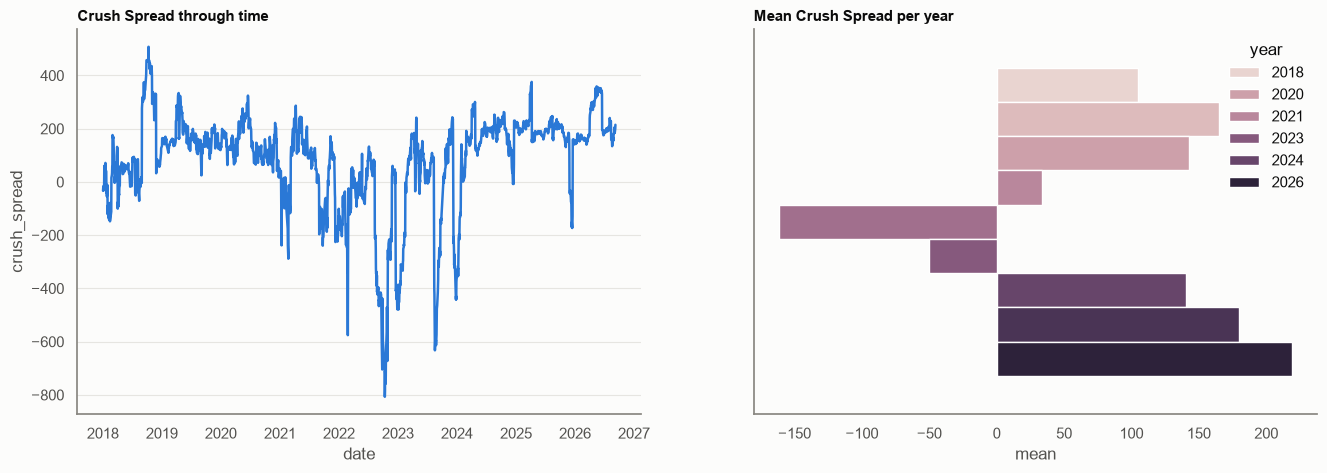

ADFullerResult
ADF Statistic: -5.09436
P-value: 0.00001
Used Lag: 0
Nobs: 2106
Critical Values: {'1%': np.float64(-3.4334588739173006), '5%': np.float64(-2.8629133710702983), '10%': np.float64(-2.5675011176676956)}

p_value: 0.000
ADFullerResult
ADF Statistic: -5.09436
P-value: 0.00001
Used Lag: 0
Nobs: 2106
Critical Values: {'1%': np.float64(-3.4334588739173006), '5%': np.float64(-2.8629133710702983), '10%': np.float64(-2.5675011176676956)}



In [5]:
 # View crush margins
fig, axs = plt.subplots(1,2, figsize=(16,5))
sns.lineplot(ts["crush_spread"], ax=axs[0])
sns.barplot(data=grouped, x="mean", hue="year", ax=axs[1])
axs[0].set_title("Crush Spread through time")
axs[1].set_title("Mean Crush Spread per year")
plt.show()

print(utilities.ad_fuller_test(ts["crush_spread"]))

### Build Kalman Filter to understand the time varying variance of the spread
Compare with simple Arima model assuming mean does not move and compare

In [6]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

crush = ts["crush_spread"]

model = UnobservedComponents(crush, level="local level", autoregressive=1)
res = model.fit(disp=False)


level = pd.Series(res.filtered_state[0], index=crush.index)
z = pd.Series(res.standardized_forecasts_error[0], index=crush.index)
P = pd.Series(res.filtered_state_cov[0, 0], index=crush.index)

res.summary()

C:\Users\Amin\PycharmProjects\Asia Ags\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                        Unobserved Components Results                         
==============================================================================
Dep. Variable:           crush_spread   No. Observations:                 2107
Model:                    local level   Log Likelihood              -10763.595
                              + AR(1)   AIC                          21535.190
Date:                Mon, 05 Oct 2026   BIC                          21557.800
Time:                        17:09:12   HQIC                         21543.470
Sample:                             0                                         
                               - 2107                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular    39.1800     30.235      1.296      0.195     -20.079      98.439
sigma2.level      1499.3752      8e+04      0.019      0.985   -1.55e+05    1.58e+05
sigma2.ar           33.5139      8e+04      0.000      1.000   -1.57e+05    1.57e+05
ar.L1                0.9998      0.718      1.393      0.164      -0.407       2.406
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            220237.00
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                            -0.39
Prob(H) (two-sided):                  0.53   Kurtosis:                        53.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
# Try Simple model - Arima
from statsmodels.tsa.arima.model import ARIMA
simple = ARIMA(crush, order=(1,0,0)).fit()
simple.summary()

C:\Users\Amin\PycharmProjects\Asia Ags\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\Amin\PycharmProjects\Asia Ags\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\Amin\PycharmProjects\Asia Ags\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           crush_spread   No. Observations:                 2107
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -10757.556
Date:                Mon, 05 Oct 2026   AIC                          21521.113
Time:                        17:09:12   BIC                          21538.072
Sample:                             0   HQIC                         21527.323
                               - 2107                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.3384     43.792      1.857      0.063      -4.492     167.169
ar.L1          0.9753      0.004    262.750      0.000       0.968       0.983
sigma2      1590.8211     12.766    124.614      0.000    1565.800    1615.842
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):            205163.02
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                            -0.66
Prob(H) (two-sided):                  0.56   Kurtosis:                        51.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Summary of phase 1 analysis:
The DCE bean2 crush is stationary around a constant mean of 81 CNY/t with a 28-day half-life (raw data - see roll check at the end). It needs no time-varying level
2022–24 collapse was a long excursion, not a regime shift.
Its horizon and fat-tailed, left-skewed payoff make it a weeks-horizon fundamental RV object.

#### Phase 2:
independent episodes = 76 (2106 observations / 28d half life)
simple trading model of [z] > & < 1.5, time stop on half like * 2 and exit at fair value.

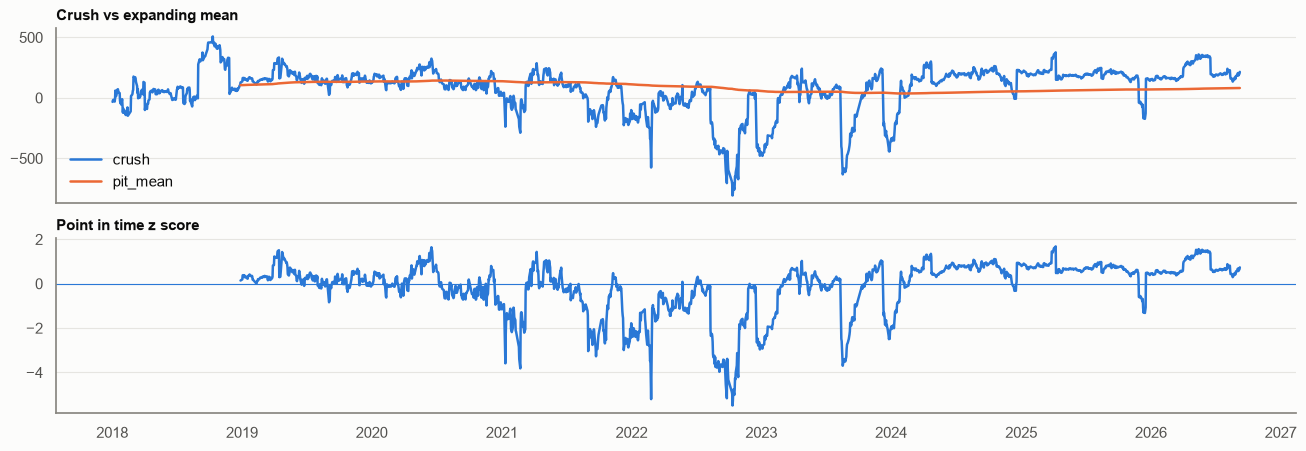

In [8]:
    # build charts, using expanding window as the mean is constant
BURN_IN = 243

crush = crush
pit_mean = crush.expanding(min_periods=BURN_IN).mean()
pit_std = crush.expanding(min_periods=BURN_IN).std()
z = ((crush - pit_mean) / pit_std).rename("z")

fig, axs = plt.subplots(2, 1, figsize=(16,5), sharex=True)
axs[0].plot(crush, label="crush")
axs[0].plot(pit_mean, label="pit_mean")
axs[0].legend(); axs[0].set_title("Crush vs expanding mean")
axs[1].plot(z); axs[1].axhline(0, lw=0.8)
axs[1].set_title("Point in time z score")
plt.show()

trades          : 11  (long 7, short 4)
exit reasons    : {'target': 11}
holding bars    : median 36, max 70
time in market  : 18.7%

--- on gross notional ---
total return    :   29.68%   over 8.7 years
annualised      :    3.42%
annualised vol  :    4.21%
Sharpe (all day):    0.81
Sharpe (in mkt) :    1.91
max drawdown    :   -6.29%
Calmar          :    0.54

--- at 10% margin (10x on notional) ---
annualised      :   34.19%
max drawdown    :  -62.92%

(sizing reference: 2571 CNY/t total, 234 CNY/t per trade)

     entry       exit  dir  bars    why
2019-04-15 2019-04-16   -1     1 target
2020-06-16 2020-07-07   -1    13 target
2021-01-11 2021-03-09    1    36 target
2021-09-01 2021-11-01    1    36 target
2021-12-08 2022-03-18    1    66 target
2022-08-11 2022-11-25    1    70 target
2022-12-19 2023-02-16    1    37 target
2023-08-14 2023-10-09    1    34 target
2023-12-14 2024-01-26    1    30 target
2025-04-02 2025-04-09   -1     4 target
2026-05-08 2026-08-13   -1    68 target


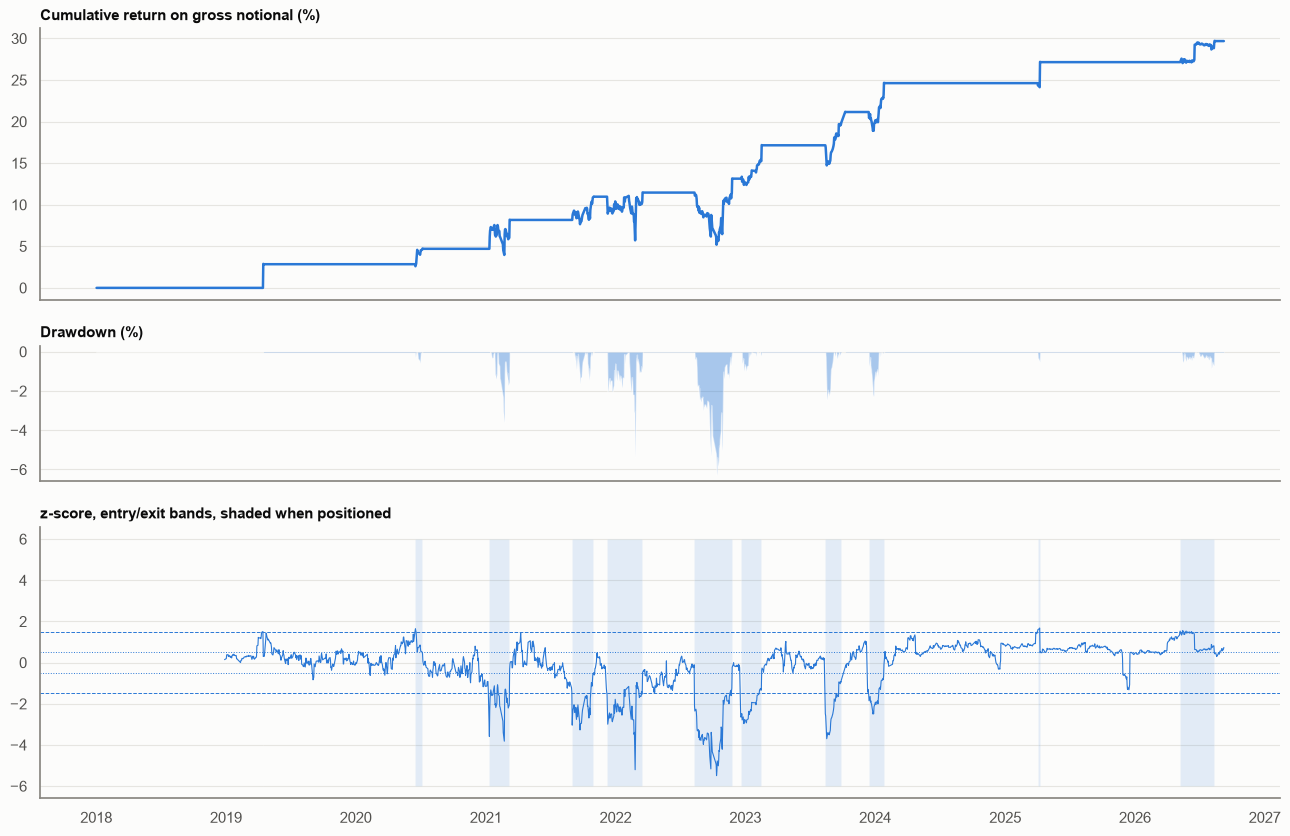

In [9]:
# Strategy logic: enter on dislocation, exit on reversion, time stop as a backstop.
# Pre-registered parameters - do not revisit these after seeing the P&L.
import numpy as np

K, J, N = 1.5, 0.5, 90    # entry sigma, exit sigma, time stop in bars
COST = 5.0                # CNY/t round trip: ~1 tick per leg weighted, + bean2 impact
MARGIN = 0.10             # assumed exchange margin, for the return-on-capital view

pos = pd.Series(0, index=z.index, dtype=int)   # position decided ON bar t
state, held, locked, entry = 0, 0, False, None
trades = []

for t in range(len(z)):
    zt = z.iloc[t]

    if not np.isnan(zt):                       # burn-in period stays flat

        # --- exits first: resolve the position we are already carrying ---
        if state != 0:
            held += 1
            if abs(zt) < J:                              # reverted to target
                trades.append((entry, z.index[t], state, held, "target"))
                state, held = 0, 0
            elif held >= N:                              # thesis invalidated
                trades.append((entry, z.index[t], state, held, "timestop"))
                state, held, locked = 0, 0, True

        # --- entries: only if flat after the exit check ---
        if state == 0:
            if locked:
                # after a time stop, wait for the spread to normalise before re-arming,
                # otherwise we exit and re-enter on the very same bar
                if abs(zt) < J:
                    locked = False
            elif zt < -K:
                state, held, entry = +1, 0, z.index[t]   # crush cheap  -> long
            elif zt > K:
                state, held, entry = -1, 0, z.index[t]   # crush rich   -> short

    pos.iloc[t] = state

trades = pd.DataFrame(trades, columns=["entry", "exit", "dir", "bars", "why"])

# A signal computed from bar t's close can only be acted on from t+1.
traded = pos.shift(1).fillna(0)

gross  = traded * crush.diff()
turns  = traded.diff().abs().fillna(0)         # 1 per open/close, 2 on a flip
net    = (gross - turns * (COST / 2)).fillna(0)

# --- Normalise to returns -------------------------------------------------
# The spread itself is a margin: it straddles zero, so it cannot be a denominator.
# The correct base is the GROSS NOTIONAL of one crush unit - the value of all three
# legs - taken point-in-time, since prices drift a long way over eight years.
notional = ts["bean2_close"] + 0.785 * ts["meal_close"] + 0.185 * ts["oil_close"]

ret = (net / notional.shift(1)).fillna(0)
# cumsum, not cumprod: sizing is fixed at one crush unit, so P&L is additive.
# Compounding would assume a reinvestment the strategy does not do.
equity = ret.cumsum()
dd     = equity - equity.cummax()
yrs    = (ret.index[-1] - ret.index[0]).days / 365.25

active = ret[traded != 0]
print(f"trades          : {len(trades)}  (long {(trades.dir==1).sum()}, short {(trades.dir==-1).sum()})")
print(f"exit reasons    : {trades.why.value_counts().to_dict()}")
print(f"holding bars    : median {trades.bars.median():.0f}, max {trades.bars.max():.0f}")
print(f"time in market  : {100*(pos!=0).mean():.1f}%")
print()
print("--- on gross notional ---")
print(f"total return    : {100*equity.iloc[-1]:7.2f}%   over {yrs:.1f} years")
print(f"annualised      : {100*equity.iloc[-1]/yrs:7.2f}%")
print(f"annualised vol  : {100*ret.std()*np.sqrt(243):7.2f}%")
print(f"Sharpe (all day): {ret.mean()/ret.std()*np.sqrt(243):7.2f}")
print(f"Sharpe (in mkt) : {active.mean()/active.std()*np.sqrt(243):7.2f}")
print(f"max drawdown    : {100*dd.min():7.2f}%")
print(f"Calmar          : {(equity.iloc[-1]/yrs)/abs(dd.min()):7.2f}")
print()
print(f"--- at {MARGIN:.0%} margin ({1/MARGIN:.0f}x on notional) ---")
print(f"annualised      : {100*(equity.iloc[-1]/yrs)/MARGIN:7.2f}%")
print(f"max drawdown    : {100*dd.min()/MARGIN:7.2f}%")
print()
print(f"(sizing reference: {net.cumsum().iloc[-1]:.0f} CNY/t total, "
      f"{net.cumsum().iloc[-1]/len(trades):.0f} CNY/t per trade)")
print()
print(trades.assign(entry=trades.entry.dt.date, exit=trades.exit.dt.date).to_string(index=False))

fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                        gridspec_kw={"height_ratios": [2, 1, 2]})
axs[0].plot(100 * equity)
axs[0].set_title("Cumulative return on gross notional (%)")
axs[1].fill_between(dd.index, 100 * dd, 0, alpha=0.4)
axs[1].set_title("Drawdown (%)")
axs[2].plot(z, lw=0.8)
for lv in (-K, K):
    axs[2].axhline(lv, ls="--", lw=0.7)
for lv in (-J, J):
    axs[2].axhline(lv, ls=":", lw=0.7)
axs[2].fill_between(pos.index, -6, 6, where=pos != 0, alpha=0.12)
axs[2].set_title("z-score, entry/exit bands, shaded when positioned")
plt.show()

                 binary  continuous
time_in_mkt_pct   18.75       88.47
ann_return_pct     3.42        5.12
ann_vol_pct        4.21        5.20
sharpe             0.81        0.99
sharpe_in_mkt      1.91        1.05
max_dd_pct        -6.29       -6.54
calmar             0.54        0.78
turns_per_yr       1.27        8.88

correlation of the two return streams: 0.802


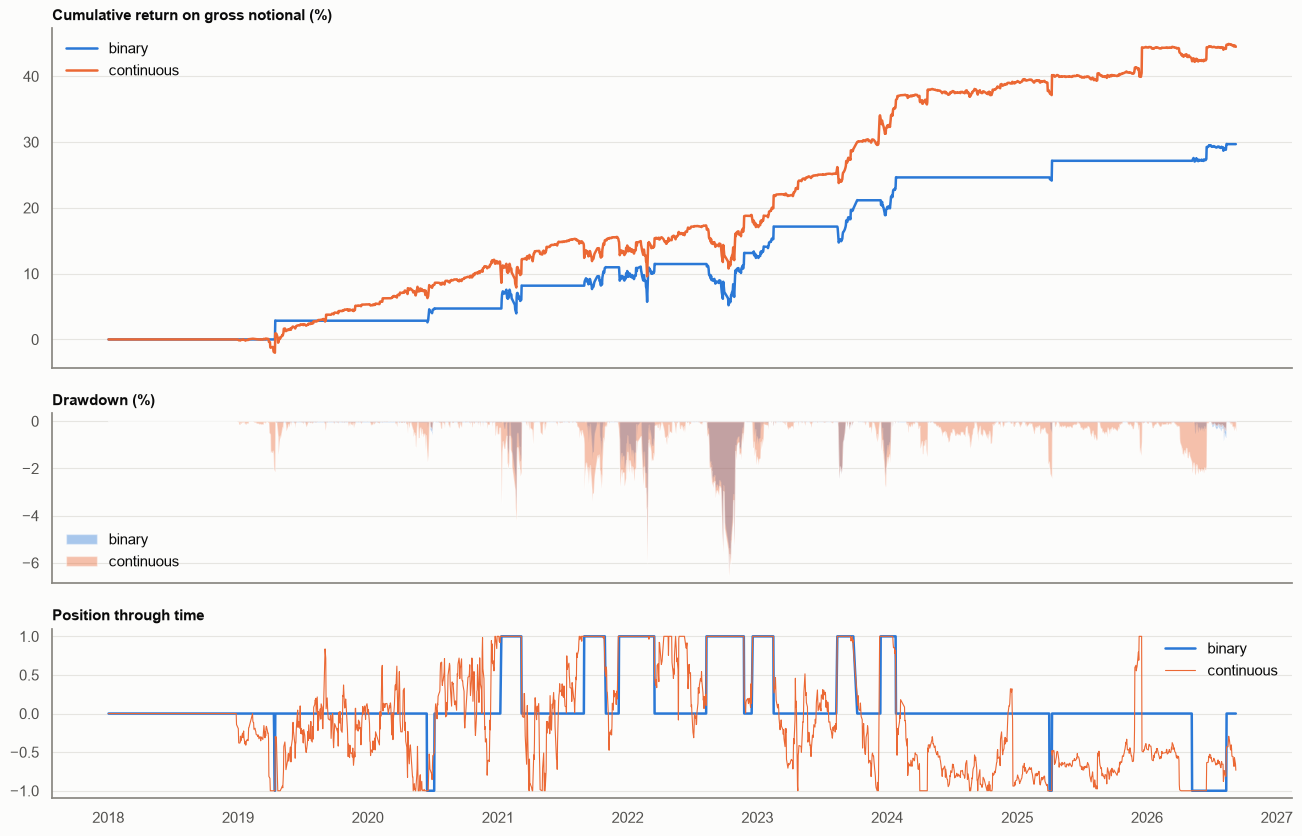

In [10]:
# continuous sizing variant - size proportional to the dislocation instead of binary
# CAP was chosen in sample by scanning 3 values, so unlike K, J, N it is not pre-registered
CAP = 1.0

def backtest(pos, crush, notional, cost=5.0):
    """ run a position series through P&L, return stats on gross notional """
    traded = pos.shift(1).fillna(0)
    gross = traded * crush.diff()
    turns = traded.diff().abs().fillna(0)
    net = (gross - turns * (cost / 2)).fillna(0)

    ret = (net / notional.shift(1)).fillna(0)
    equity = ret.cumsum()
    dd = equity - equity.cummax()
    yrs = (ret.index[-1] - ret.index[0]).days / 365.25
    active = ret[traded != 0]

    stats = {
        "time_in_mkt_pct": 100 * (traded != 0).mean(),
        "ann_return_pct": 100 * equity.iloc[-1] / yrs,
        "ann_vol_pct": 100 * ret.std() * np.sqrt(243),
        "sharpe": ret.mean() / ret.std() * np.sqrt(243),
        "sharpe_in_mkt": active.mean() / active.std() * np.sqrt(243),
        "max_dd_pct": 100 * dd.min(),
        "calmar": (equity.iloc[-1] / yrs) / abs(dd.min()),
        "turns_per_yr": traded.diff().abs().sum() / 2 / yrs,
    }
    return stats, equity, dd

# binary comes from the loop above, continuous is just -z capped
pos_cont = (-z).clip(-CAP, CAP).fillna(0)

bin_stats, bin_eq, bin_dd = backtest(pos, crush, notional)
con_stats, con_eq, con_dd = backtest(pos_cont, crush, notional)

compare = pd.DataFrame({"binary": bin_stats, "continuous": con_stats}).round(2)
print(compare)
print()
print("correlation of the two return streams:", round(bin_eq.diff().corr(con_eq.diff()), 3))

fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                        gridspec_kw={"height_ratios": [2, 1, 1]})
axs[0].plot(100 * bin_eq, label="binary")
axs[0].plot(100 * con_eq, label="continuous")
axs[0].legend(); axs[0].set_title("Cumulative return on gross notional (%)")

axs[1].fill_between(bin_dd.index, 100 * bin_dd, 0, alpha=0.4, label="binary")
axs[1].fill_between(con_dd.index, 100 * con_dd, 0, alpha=0.4, label="continuous")
axs[1].legend(); axs[1].set_title("Drawdown (%)")

axs[2].plot(pos, label="binary")
axs[2].plot(pos_cont, lw=0.8, label="continuous")
axs[2].legend(); axs[2].set_title("Position through time")
plt.show()

#### Phase 3: roll check and horizon test
Continuous contracts gap at each roll. DCE daily limits are ~4-7%, so any leg move > 6% is a roll, not a trade.

In [11]:
import statsmodels.api as sm

jumps = pd.Series(False, index=ts.index)
for col in ["bean2_close", "meal_close", "oil_close"]:
    jumps |= np.log(ts[col]).diff().abs() > 0.06

gross = traded * crush.diff()
print(f"roll days       : {jumps.sum()}")
print(f"entries on roll : {trades.entry.isin(crush.index[jumps]).sum()} of {len(trades)}")
print(f"gross on rolls  : {gross[jumps].sum():.0f} of {gross.sum():.0f} CNY/t")

# zero out roll days and rebuild - crude back adjust, the level drifts so only trust it at short horizons
crush_clean = crush.diff().where(~jumps, 0).fillna(0).cumsum() + crush.iloc[0]

def half_life(s):
    y = s.diff().dropna()
    b = sm.OLS(y, sm.add_constant(s.shift(1).loc[y.index])).fit().params.iloc[1]
    return np.log(0.5) / np.log(1 + b)

print()
print(f"half-life raw   : {half_life(crush):.0f}d")
print(f"half-life clean : {half_life(crush_clean):.0f}d")

roll days       : 20
entries on roll : 4 of 11
gross on rolls  : 893 of 2626 CNY/t

half-life raw   : 28d
half-life clean : 497d


Horizon test - does distance from an anchor predict the next h-day change? Non-overlapping samples, clean series.

In [12]:
anchors = {
    "expanding": crush_clean.expanding(BURN_IN).mean(),
    "ma60": crush_clean.rolling(60).mean(),
    "ma20": crush_clean.rolling(20).mean(),
    "ma10": crush_clean.rolling(10).mean(),
}

rows = {}
for name, a in anchors.items():
    dev = crush_clean - a
    for h in [1, 5, 10, 20]:
        fwd = crush_clean.shift(-h) - crush_clean
        d = pd.concat([dev, fwd], axis=1).dropna().iloc[::h]
        r = sm.OLS(d.iloc[:, 1], sm.add_constant(d.iloc[:, 0])).fit(cov_type="HAC", cov_kwds={"maxlags": 2})
        rows[(name, h)] = r.tvalues.iloc[1]

print("t-stats, rows = anchor, cols = horizon (days)")
print(pd.Series(rows).unstack().round(1))
print()
print(f"1d change sd : {crush_clean.diff().std():.1f}")
print(f"5d change sd : {(crush_clean.shift(-5) - crush_clean).std():.1f}   (random walk = {crush_clean.diff().std() * np.sqrt(5):.1f})")

t-stats, rows = anchor, cols = horizon (days)
            1    5    10   20
expanding -0.8 -0.9 -0.8 -0.5
ma10      -0.7  0.3 -0.9 -2.0
ma20      -0.7 -0.1 -0.7 -0.7
ma60      -0.5 -0.1 -0.2 -0.6

1d change sd : 29.7
5d change sd : 65.6   (random walk = 66.5)


#### Conclusion
Not tradeable at a weekly horizon.
- 4 of 11 entries fell on a roll day and ~1/3 of gross P&L came from roll gaps. The 28d half-life is mostly roll artifact - true half-life needs a matched-contract crush.
- No anchor predicts the next 1-20 day change. The 5d sd is exactly the random walk value.
- The physical tie is real but works through crush run rates and imports over months - the PM's horizon, not mine.

Use the crush as a fair value map for direction. Weekly timing has to come from a faster information source.